In [1]:
# FASE 3: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuración visual 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Cargar el dataset limpio
df_eda = pd.read_csv('../Data/airbnb_limpio_final.csv')
print("Dataset cargado para EDA. Dimensiones:", df_eda.shape)

Dataset cargado para EDA. Dimensiones: (21448, 79)


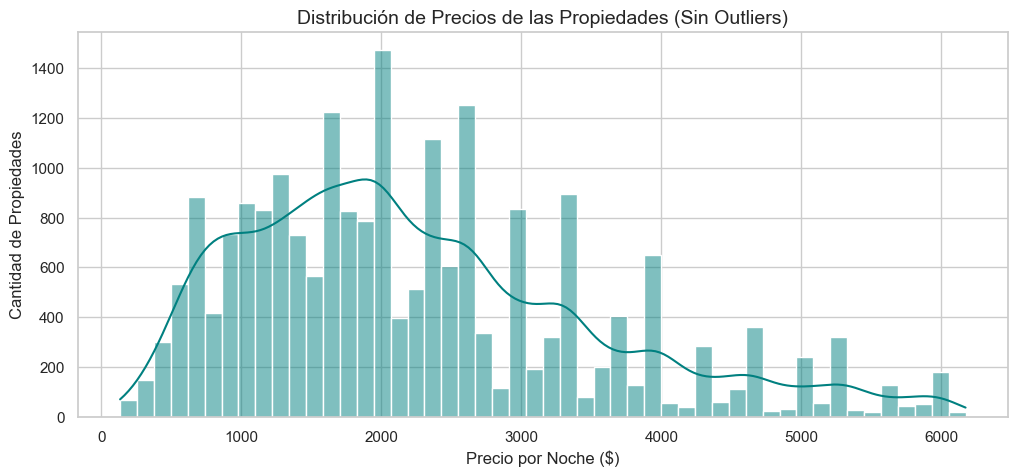

In [3]:
# --- GRÁFICO 1: Distribución de Precios ---
plt.figure(figsize=(12, 5))
sns.histplot(df_eda['price'], bins=50, kde=True, color='teal')
plt.title('Distribución de Precios de las Propiedades (Sin Outliers)', fontsize=14)
plt.xlabel('Precio por Noche ($)', fontsize=12)
plt.ylabel('Cantidad de Propiedades', fontsize=12)
plt.show()

C:\Users\aguub\AppData\Local\Temp\ipykernel_7068\4025515693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='room_type', y='price', estimator='mean', order=orden_room, palette='viridis', errorbar=None)


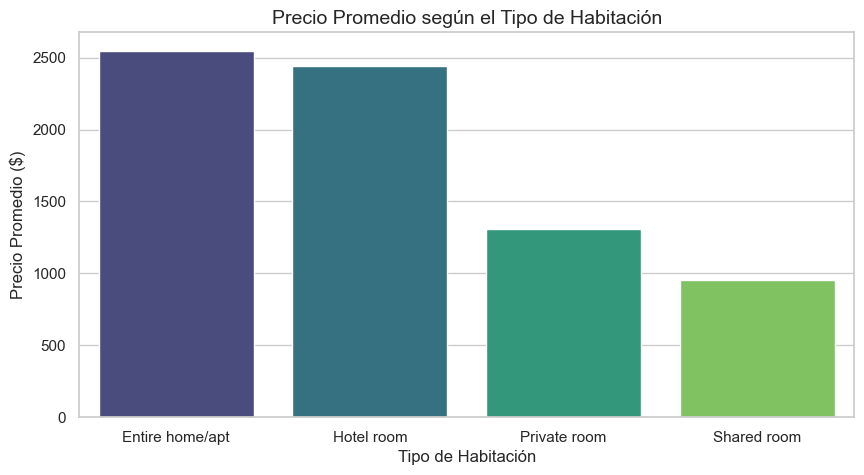

In [4]:
# --- GRÁFICO 2: Precio Promedio por Tipo de Habitación ---
plt.figure(figsize=(10, 5))
# Calculamos el orden para que el gráfico quede de mayor a menor
orden_room = df_eda.groupby('room_type')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_eda, x='room_type', y='price', estimator='mean', order=orden_room, palette='viridis', errorbar=None)
plt.title('Precio Promedio según el Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio Promedio ($)', fontsize=12)
plt.show()

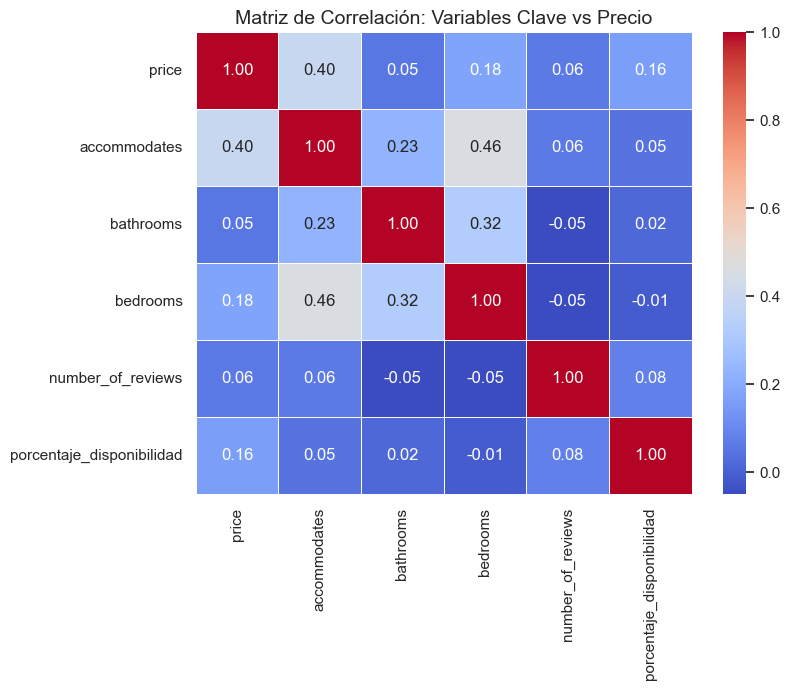

In [6]:
# --- GRÁFICO 3: Mapa de Calor de Correlaciones ---
# Seleccionamos solo algunas variables numéricas clave para no saturar
variables_num = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'porcentaje_disponibilidad']
# Filtramos para asegurarnos de que existan en el df
variables_existentes = [var for var in variables_num if var in df_eda.columns]

plt.figure(figsize=(8, 6))
matriz_correlacion = df_eda[variables_existentes].corr()
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables Clave vs Precio', fontsize=14)
plt.show()

C:\Users\aguub\AppData\Local\Temp\ipykernel_7068\806498269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios_cantidad.values, y=top_barrios_cantidad.index, palette='Blues_r')


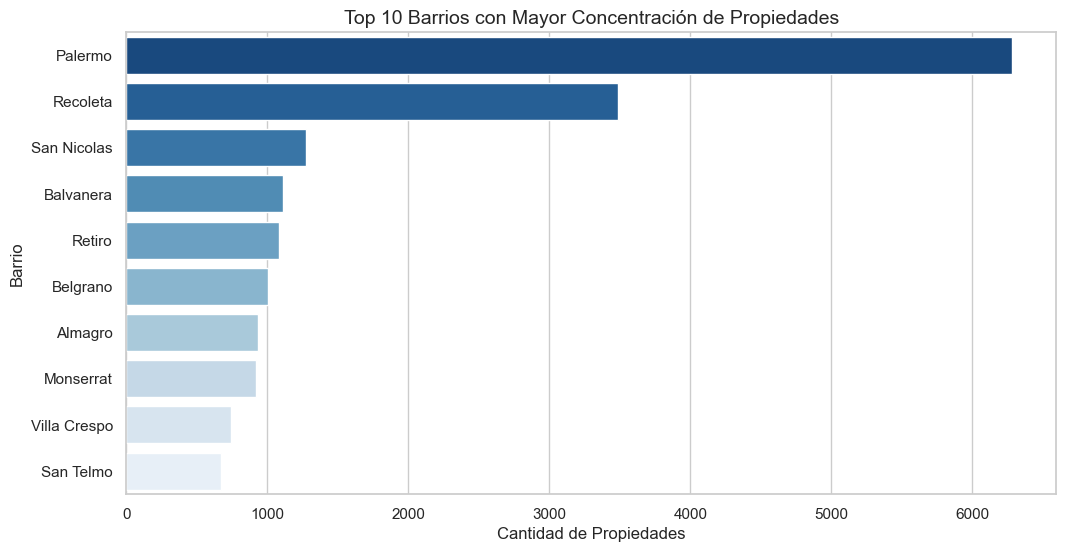

In [8]:
# --- GRÁFICO 4: Top 10 Barrios con Mayor Oferta (Cantidad de Propiedades) ---
plt.figure(figsize=(12, 6))
# Contamos cuántas propiedades hay por barrio y nos quedamos con los 10 primeros
top_barrios_cantidad = df_eda['neighbourhood_cleansed'].value_counts().head(10)

# Graficamos
sns.barplot(x=top_barrios_cantidad.values, y=top_barrios_cantidad.index, palette='Blues_r')
plt.title('Top 10 Barrios con Mayor Concentración de Propiedades', fontsize=14)
plt.xlabel('Cantidad de Propiedades', fontsize=12)
plt.ylabel('Barrio', fontsize=12)
plt.show()



C:\Users\aguub\AppData\Local\Temp\ipykernel_7068\3856408982.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios_precio.values, y=top_barrios_precio.index, palette='flare')


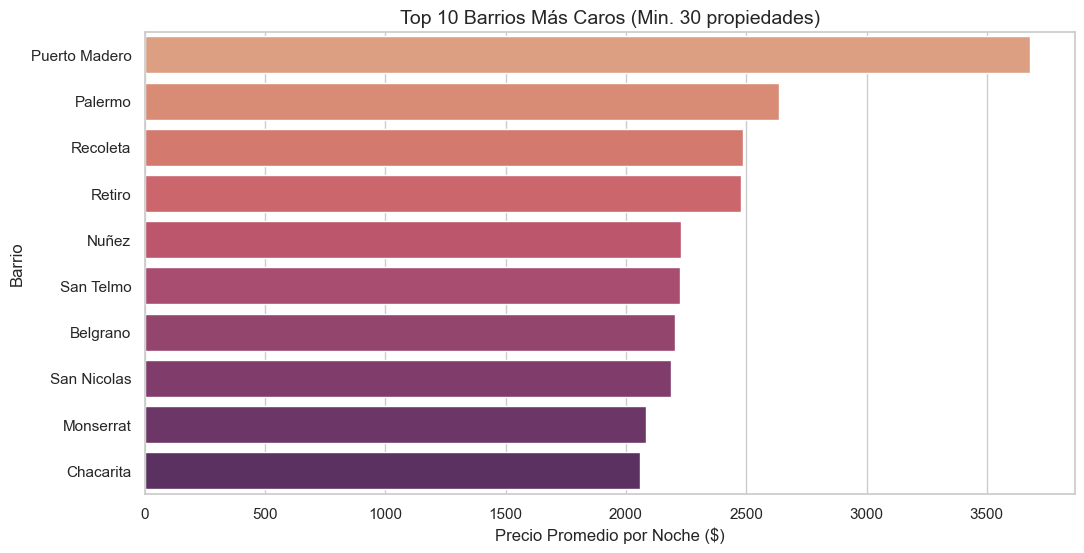

In [9]:
# --- GRÁFICO 5: Top 10 Barrios Más Caros (Precio Promedio) ---
# 1. Regla de negocio: Filtramos barrios que tengan al menos 30 propiedades
conteos_barrio = df_eda['neighbourhood_cleansed'].value_counts()
barrios_representativos = conteos_barrio[conteos_barrio >= 30].index
df_barrios_robustos = df_eda[df_eda['neighbourhood_cleansed'].isin(barrios_representativos)]

# 2. Calculamos el precio promedio solo de esos barrios representativos
top_barrios_precio = df_barrios_robustos.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_barrios_precio.values, y=top_barrios_precio.index, palette='flare')
plt.title('Top 10 Barrios Más Caros (Min. 30 propiedades)', fontsize=14)
plt.xlabel('Precio Promedio por Noche ($)', fontsize=12)
plt.ylabel('Barrio', fontsize=12)
plt.show()